# Implementação do projeto do capítulo 2

### Instalando os pacotes necessários:
- matplotlib
- numpy
- pandas
- scipy
- scikit-learn

In [1]:
pip install -U matplotlib numpy pandas scipy scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Fazendo o download dos dados:

Vamos criar uma função que faça o download automático dos dados e faça a extração automática dos dados. Em um projeto real criaríamos essa função em um arquivo python dedicado, porém, por hora, vamos criar aqui.

In [3]:
import os
import tarfile
import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

# Cria os diretórios dataset e housing, define o caminho do arquivo housing.tgz, faz a requisição informando o que e aonde irá ser armazenado o arquivo, abre o arquivo tgz e extrai
def fetch_housing_data(housing_url = HOUSING_URL, housing_path = HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()
    
fetch_housing_data()

Agora vamos ler o arquivo housing.csv obtido após a extração utilizando a biblioteca pandas:

In [5]:
import pandas as pd

def load_housing_data(housing_path = HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing_df = load_housing_data()

### Analisando a estrutura dos dados:

Agora vamos começar a brincar um pouco com os dados:

In [ ]:
# Visualizando as 5 primeiras linhas do dataset
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Visualizando dados gerais do dataset
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [ ]:
# Visualizando as categorias do atributo ocean_proximity
housing_df.ocean_proximity.unique()

<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

In [ ]:
# Visualizando a quantidade de registros por categoria de proximidade com o oceano
housing_df.ocean_proximity.value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [28]:
# Visualizando características gerais das variáveis numéricas:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<BarContainer object of 5 artists>

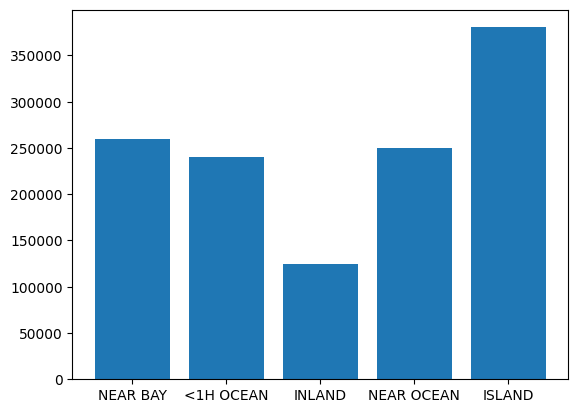

In [ ]:
import matplotlib.pyplot as plt

mediaNo = housing_df[housing_df.ocean_proximity == "NEAR OCEAN"].median_house_value.mean()
media1 = housing_df[housing_df.ocean_proximity == "<1H OCEAN"].median_house_value.mean()
mediaIn = housing_df[housing_df.ocean_proximity == "INLAND"].median_house_value.mean()
mediaNb = housing_df[housing_df.ocean_proximity == "NEAR BAY"].median_house_value.mean()
mediaIs = housing_df[housing_df.ocean_proximity == "ISLAND"].median_house_value.mean()

plt.bar(housing_df.ocean_proximity.unique(), [mediaNb, media1, mediaIn, mediaNo, mediaIs])

## A partir da análise do gráfico de colunas, percebemos que quanto maior a proximidade com o oceano, maior é o preço médio dos imóveis

/var/folders/8n/06x95xg133171h7d8svqmzc00000gn/T/ipykernel_59545/3445669800.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([near_ocean, near_bay, inland, island, hour_ocean], labels=["Near Ocean", "Near Bay", "Inland", "Island", "<1h Ocean"])


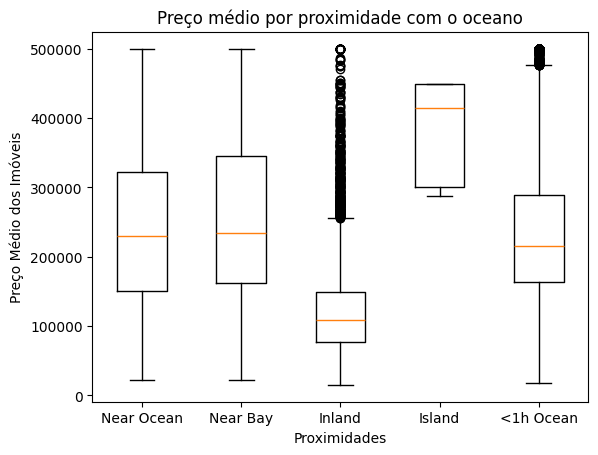

In [ ]:
# Criando um gráfico de boxplot de preço médio por proximidade com o oceano
near_ocean = housing_df[housing_df.ocean_proximity == "NEAR OCEAN"].median_house_value
near_bay = housing_df[housing_df.ocean_proximity == "NEAR BAY"].median_house_value
inland = housing_df[housing_df.ocean_proximity == "INLAND"].median_house_value
island = housing_df[housing_df.ocean_proximity == "ISLAND"].median_house_value
hour_ocean = housing_df[housing_df.ocean_proximity == "<1H OCEAN"].median_house_value

plt.boxplot([near_ocean, near_bay, inland, island, hour_ocean], labels=["Near Ocean", "Near Bay", "Inland", "Island", "<1h Ocean"])
plt.title('Preço médio por proximidade com o oceano')
plt.xlabel('Proximidades')
plt.ylabel('Preço Médio dos Imóveis')
plt.show()